# Land Surface Temperature and Normalised Different Vegetation Index in Brussels

### Introduction

In this notebook, we investigate the link between the Land Surface Temperature (LST) and the Normalised Difference Vegetation Index (NDVI) for Brussels, the capital city of Belgium. 

With rising temperatures due to global warming, factors contributing to higher LST across the globe are widely studied. More specifically, some papers look at indices such as the Normalised Difference Vegetation Index (NDVI), Normalised Difference Building Index (NDBI), (Modified) Normalised Difference Water (MNDWI), etc. as drivers for elevated LST (see e.g. Roy and Bari (2022) among others). 

In this notebook we focus on one such index, the NDVI. The focus is on extracting LST and NDVI from the Sentinel-2 and Sentinel-3 missions using the newly adapted zarr data format from the EOPF Sentinel Zarr Samples project. 

We mainly focus on extracting the zarr data for NDVI and LST and do some initial exploratory analysis and see at a high level if we can observe some patterns. In future work, we will continue this work and look at a statistical analysis (correlation, regression, etc.) between LST and NDVI. 




### What we will learn


- 🚀 How to extract over a given Area of Interest (AOI) and time period both Land Surface Temperatures (LST) and Normalised Difference Vegetation Index (NDVI) from scratch.
- 🌐 How to query to extract Sentinel-2 and Sentinel-3 using a geometry in Pystac rather than latitude-longitude corner coordinates and how to find the Sentinel-2 UTM tiles.
- 🔎 How to find and apply filters for Sentinel-2 based on a step-by-step approach using filters for:
  
        - cloud cover
        - Sentinel 2 tile
        - time period
        - data depreciated or not
- 🛰️ Using filters for Sentinel-3:
  
        - Near Real Time (NT) or Non-Time Critical images
        - Data deprecated or not
        - time period

- ✔️ Compute Normalised Difference Vegetation Index (NDVI) and Land Surface Temperature (LST) for the same AOI and date using the extracted Sentinel-2 and Sentinel-3 data.
- 🌍 How to clip Sentinel-2 (True Color image and NDVI) and Sentinel-3 (LST) data based on a geometry (other than longitude and longitude).
- 🗺️ Visualisation of NDVI and LST.

### Prerequisites

In order to be able to run this tutorial, you need to install extra Python packages. 

In [1]:
!pip install folium mapclassify --quiet

#### Import libraries

In [2]:
from datetime import datetime

import folium  #  noqa: F401
import geopandas as gpd
import mapclassify #  noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from distributed import LocalCluster
from pystac import MediaType
from pystac_client import Client
from scipy.interpolate import griddata

<hr>

## Set-up

### Reading in the Area of Interest

Here, you can specify your file path for your Area of Interest (AOI) or upload your file for your region of interest.

In [3]:
## Please uncomment this line if you want to run this script from scratch
## brussels_file_path = 'https://github.com/EllenB/eopf/releases/download/data/brussels_dissolved.geojson'   

In [4]:
# !wget -O brussels_dissolved.geojson \
# $brussels_file_path

<Axes: >

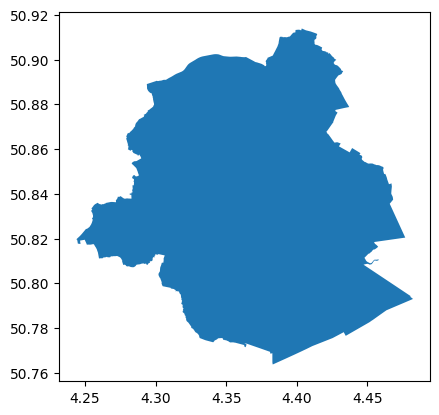

In [5]:
gdf = gpd.read_file('brussels_dissolved.geojson')
gdf.plot()

### Setting up a Dask cluster

In [6]:
cluster = LocalCluster()
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 10.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44093,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41757,Total threads: 1
Dashboard: http://127.0.0.1:41783/status,Memory: 2.50 GiB
Nanny: tcp://127.0.0.1:35747,


### Connection to the EOPF catalog

This is the link to the EOPF catalog from which we will retrieve our data from: 

In [7]:
eopf_catalog = Client.open(url="https://stac.core.eopf.eodc.eu/")

In this tutorial, we will use the Sentinel-2 and Sentinel-3 collections but the eopf catalog consists of more collections:

In [8]:
for collection in eopf_catalog.get_all_collections():
        print(collection.id)

sentinel-2-l2a
sentinel-1-l1-grd
sentinel-3-slstr-l2-lst
sentinel-1-l2-ocn
sentinel-3-slstr-l2-frp
sentinel-3-olci-l2-lfr
sentinel-3-olci-l2-lrr
sentinel-3-olci-l1-efr
sentinel-3-slstr-l1-rbt
sentinel-2-l1c
sentinel-1-l1-slc
sentinel-3-olci-l1-err


## Sentinel 2: True colour composite and Normalised Difference Vegetation Index

To create a map for the Brussels are with the true color composite and the NDVI index, we will have to use the sentinel-2-l2a collection. 

### Parameters

Since lots of images are not yet in the zarr catalog, we start with a rather broad search and define the parameters over a long time period:

In [9]:
period = "2025-01-01/2026-03-08"
aoi = gdf.geometry.iloc[0].__geo_interface__

When using a Geopandas dataset, we need to use "__geo_interface__" (please see the [pystac-client documentation](https://pystac-client.readthedocs.io/en/latest/api.html)). 

To search the Sentinel-2 EOPF catalog, you can use the following command using pystac:

### Finding the right Sentinel-2 image

In [10]:
items_s2 = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    datetime=period
   ).item_collection()

/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UFS_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UES_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2A_MSIL2A_20251102T105231_N0511_R051_T31UFS_20251102T144301' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2B_MSIL2A_20251102T104109_N0511_R008_T31UES_20251102T112516' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251031T105221_N0511_R051_T31UFS_20251031T144221' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The it

We notice a lot of warnings above and these are data are actually deprecated. Below, we will show how to filter these items out. Before this, let's count the number of items from this Sentinel-2 collection:

In [11]:
print(f'There are {len(items_s2)} items in the collection')

There are 223 items in the collection


Show the first 10 items in the collection:

In [12]:
for item in items_s2[0:10]:
    print(item)

<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UFS_20260307T161311>
<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UES_20260307T161311>
<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UFS_20260305T144521>
<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UFS_20260302T161544>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544>
<Item id=S2C_MSIL2A_20260228T105001_N0512_R051_T31UFS_20260228T145912>
<Item id=S2C_MSIL2A_20260228T105001_N0512_R051_T31UES_20260228T145912>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UFS_20260225T144110>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UES_20260225T144110>


To learn a bit about the data, let's have a look at one item:

In [13]:
item_s2 = items_s2[0]
item_s2

<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UFS_20260307T161311>

Expanding this item and especially doing so for the "properties", we can learn many interesting things such as the percentage cloud cover, the Sentinel-2 UTM tile, etc. Before proceeding, it would be good to see what the Sentinel-2 tiles look like with respect to our area of interest in order to narrow our search a bit. 

To do so, we use the Folium Python library. More specifically, we notice that the print output above includes the following two tiles: 31UES and 31UFS. We put the stac search results into a Geopandas dataframe: 

In [14]:
df = gpd.GeoDataFrame.from_features(items_s2.to_dict(), crs="epsg:4326")
df.head()

,geometry,gsd,created,mission,sci:doi,updated,datetime,platform,grid:code,proj:bbox,...,processing:version,product:timeliness,sat:absolute_orbit,sat:relative_orbit,view:sun_elevation,processing:facility,processing:software,eopf:instrument_mode,product:timeliness_category,sat:platform_international_designator
0,"POLYGON ((4.43705 51.38253, 4.46157 51.44192, ...",10.0,2026-03-07T20:23:58.515446Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-07T20:23:58.515446Z,2026-03-07T10:39:11.025000Z,sentinel-2c,MGRS-31UFS,"[4.408715109637645, 50.42629366061962, 6.01702...",...,05.12,PT3H,7843,8,57.743626,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
1,"POLYGON ((4.06085 50.45675, 4.11126 50.58199, ...",10.0,2026-03-07T20:10:21.545416Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-07T20:10:21.545416Z,2026-03-07T10:39:11.025000Z,sentinel-2c,MGRS-31UES,"[4.060847991024338, 50.453523278919015, 4.5795...",...,05.12,PT3H,7843,8,58.057908,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
2,"POLYGON ((5.96823 50.65046, 5.92752 50.57, 5.8...",10.0,2026-03-05T16:52:48.306021Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-05T16:52:48.306021Z,2026-03-05T10:50:29.024000Z,sentinel-2b,MGRS-31UFS,"[4.408715109637645, 50.42811512309479, 6.01702...",...,05.12,PT3H,46981,51,58.060884,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
3,"POLYGON ((2.99971 51.45118, 4.57954 51.44054, ...",10.0,2026-03-05T16:53:15.098032Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-05T16:53:15.098032Z,2026-03-05T10:50:29.024000Z,sentinel-2b,MGRS-31UES,"[2.999712175851301, 50.453523278919015, 4.5795...",...,05.12,PT3H,46981,51,58.332325,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
4,"POLYGON ((4.4369 51.3775, 4.44514 51.39754, 4....",10.0,2026-03-02T21:27:51.801395Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-02T21:27:51.801395Z,2026-03-02T10:38:49.024000Z,sentinel-2b,MGRS-31UFS,"[4.408715109637645, 50.42629366061962, 6.01702...",...,05.12,PT3H,46938,8,59.690829,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A


In order to see the relevant Sentinel-2 tiles, one way is to do a Folium plot:

In [15]:
## Code adapted from:
## https://stacspec.org/en/tutorials/reading-stac-planetary-computer/
## https://courses.spatialthoughts.com/python-dataviz.html#multi-layer-interactive-maps
m = df[["geometry", "datetime", "grid:code", "eo:cloud_cover"]].explore(column = 'grid:code',style_kwds={"fillOpacity": 0.9})
m = gdf.explore(m=m, color = 'red')
m

If you hover over the tiles, we see that the AOI covers two tiles: 31UES and 31UFS. In what follows, we will select only the tile 31UES. Otherwise, we will also have to create a mosaic which is beyond the scope of this tutorial. Next, we create some filters for cloud cover, the Sentinel 2 tile (grid:code) and whether the data have been deprecated or not (and hence no url exists):

In [16]:
filters = {
    "eo:cloud_cover":{"lt":20},
    "deprecated":{'eq': False},
    "grid:code": {'eq': "MGRS-31UES"}
 }

Do a new search:

In [17]:
items_s2_filtered = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    query = filters,
    datetime=period
   ).item_collection()

In [18]:
print(f'There are {len(items_s2_filtered)} items in the S2-collection')

There are 5 items in the S2-collection


In [19]:
for item in items_s2_filtered:
    print(item)

<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UES_20260225T144110>
<Item id=S2B_MSIL2A_20260104T105339_N0511_R051_T31UES_20260104T125442>
<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829>


Let's select the image with the least cloud cover. According to this tutorial, there should be a quicklook image such that we can have a quick look at the data coverage:

In [20]:
## Code based on:
## https://stacspec.org/en/tutorials/reading-stac-planetary-computer/
item_least_cloud = min(items_s2_filtered, key=lambda item: item.properties["eo:cloud_cover"])
item_least_cloud.id

'S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544'

In [21]:
item_assets_least_cloud = item_least_cloud.get_assets(media_type=MediaType.ZARR)
item_assets_least_cloud

{'SR_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r10m>,
 'SR_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r20m>,
 'SR_60m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r60m>,
 'AOT_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/quality/atmosphere/r10m/aot>,
 'B01_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/p

Based on this [EOPF tutorial](https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html#prerequisites), we wanted to have a quick look at the image but noticed that there was no option to do so. Moreover, we noticed that we could not create a filter based on the "no data" in pystac as this variable was not available to our knowledge. Instead, we created a quick RGB visualisation based on [this](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/610_s2_s3_fusion.html) and this [tutorial](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/61_sardinia_s2_tfci.html). 

In [22]:
## Obtain the url for the least cloudy image
cloud_storage_least_cloud = item_assets_least_cloud['product'].href
print(cloud_storage_least_cloud)

https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr


In [23]:
dt_least_cloud = xr.open_datatree(
    cloud_storage_least_cloud,     
    engine="zarr",
    chunks="auto"      
)

/opt/conda/lib/python3.12/site-packages/xarray_sentinel/esa_safe.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


A great way to understand these data (if you are using this for the first time is to print it). Please uncomment the following line if you want to learn more:

In [24]:
## dt_least_cloud

We notice that there are several under which the data fall:

In [25]:
for dt_group in sorted(dt_least_cloud.groups):
    print("DataTree group {group_name}".format(group_name=dt_group)) 

DataTree group /
DataTree group /conditions
DataTree group /conditions/geometry
DataTree group /conditions/mask
DataTree group /conditions/mask/detector_footprint
DataTree group /conditions/mask/detector_footprint/r10m
DataTree group /conditions/mask/detector_footprint/r20m
DataTree group /conditions/mask/detector_footprint/r60m
DataTree group /conditions/mask/l1c_classification
DataTree group /conditions/mask/l1c_classification/r60m
DataTree group /conditions/mask/l2a_classification
DataTree group /conditions/mask/l2a_classification/r20m
DataTree group /conditions/mask/l2a_classification/r60m
DataTree group /conditions/meteorology
DataTree group /conditions/meteorology/cams
DataTree group /conditions/meteorology/ecmwf
DataTree group /measurements
DataTree group /measurements/reflectance
DataTree group /measurements/reflectance/r10m
DataTree group /measurements/reflectance/r20m
DataTree group /measurements/reflectance/r60m
DataTree group /quality
DataTree group /quality/atmosphere
Data

In order to visualise the RGB image, we need to obtain the Red(R)-Green(G)-Blue(B) bands and need to obtain these bands from the "measurements" group. We choose to use the 20 metres resolution:

In [26]:
least_cloud_meas = dt_least_cloud.measurements.reflectance.r20m
least_cloud_meas

<xarray.DataTree 'r20m'>
Group: /measurements/reflectance/r20m
    Dimensions:  (y: 5490, x: 5490)
    Coordinates:
      * y        (y) float32 22kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
      * x        (x) float32 22kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    Data variables:
        b01      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b02      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b03      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b04      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b05      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b06      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b07      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b11      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b12      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b8a      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>

### The true color image

In [27]:
## Code adapted from:
## https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/610_s2_s3_fusion.html
rgb_least_cloud = least_cloud_meas.to_dataset()[["b04", "b03", "b02"]].to_array()
## rgb_least_cloud # Please uncomment if you want to see this

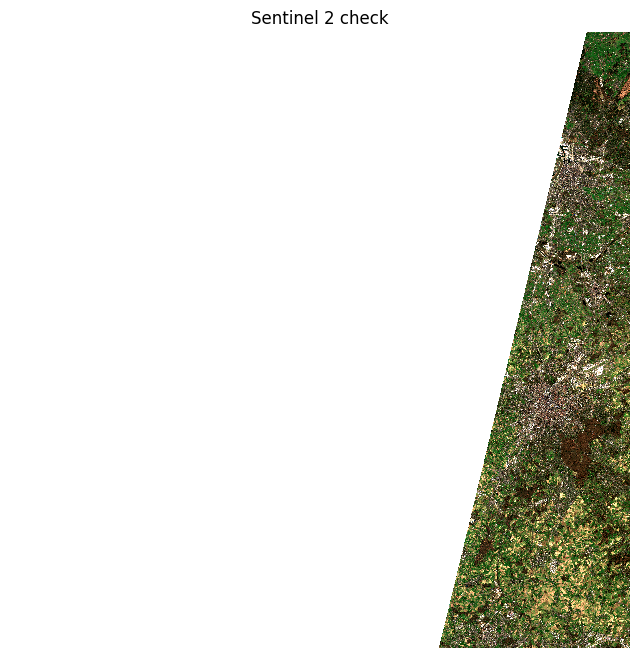

In [28]:
rgb_least_cloud.plot.imshow(figsize=(8, 8), robust=True)
plt.title("Sentinel 2 check")
plt.axis("off")
plt.show()

We think that the AOI falls within this image and we can check this using another Folium plot after some data processing in the df geopandas file created above but it is beyond the scope of this tutorial to do so. Instead, we select an image with full coverage after some trail and error:

In [29]:
item = items_s2_filtered[0]

In [30]:
item_assets = item.get_assets(media_type=MediaType.ZARR)
##item_assets

In [31]:
cloud_storage = item_assets['product'].href

print('URL:',cloud_storage)

URL: https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/05/products/cpm_v262/S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521.zarr


Now that we have found the right Sentinel-2 image, let us show it for the Brussels area. First, we show the RGB image for the entire area similar to the code above:

In [32]:
dt_s2 = xr.open_datatree(
    cloud_storage,
    engine="zarr",
    chunks="auto"
)

In [33]:
dt_meas_s2 = dt_s2.measurements.reflectance.r20m
dt_meas_s2

<xarray.DataTree 'r20m'>
Group: /measurements/reflectance/r20m
    Dimensions:  (y: 5490, x: 5490)
    Coordinates:
      * y        (y) float32 22kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
      * x        (x) float32 22kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    Data variables:
        b01      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b02      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b03      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b04      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b05      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b06      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b07      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b11      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b12      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b8a      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>

In [34]:
rgb = dt_meas_s2.to_dataset()[["b04", "b03", "b02"]].to_array()
## rgb # Please uncomment if you want to see this

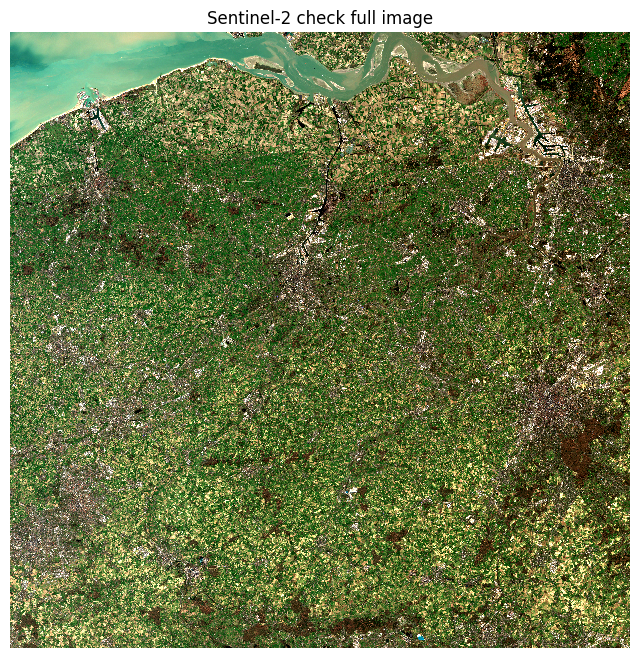

In [35]:
rgb.plot.imshow(figsize=(8, 8), robust=True)
plt.title("Sentinel-2 check full image")
plt.axis("off")
plt.show()

Our AOI lies a bit above the lower right corner and the image looks clear and does not look it has cloud cover. Let's nevertheless look at the cloud mask before proceeding:

In [36]:
## Code adapted from:
## https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/610_s2_s3_fusion.html
scl_class = dt_s2.conditions.mask.l2a_classification.r20m.scl
## scl_class ## Please uncomment to see this DataArray

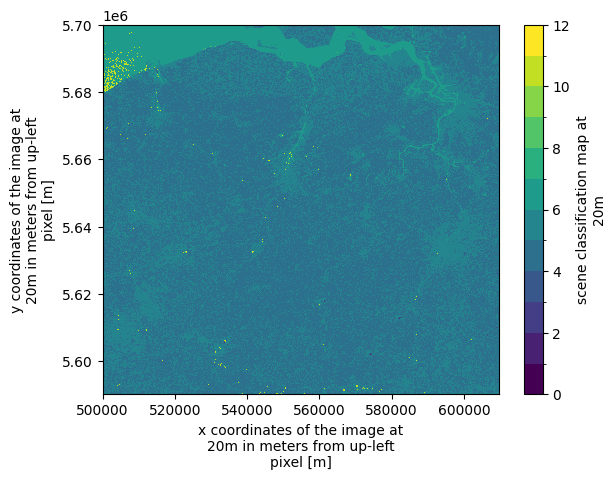

In [37]:
# https://docs.xarray.dev/en/latest/user-guide/plotting.html
# Fix plot for a better looking plot
scl_class.plot(levels = [0, 1, 2, 3,4,5,6,7,8,9,10,11, 12])

There is very little cloud in our image and especially so in our ROI, so we proceed with this image. The little yellow pixels in this image refer to the SCL class 11 which stands for thin cirrus clouds. Please see [here](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/) for the SCL legend. 

### The NDVI image

In [38]:
data = dt_s2['/measurements/reflectance/r20m'].to_dataset()
data

<xarray.Dataset> Size: 2GB
Dimensions:  (y: 5490, x: 5490)
Coordinates:
  * y        (y) float32 22kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
  * x        (x) float32 22kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
Data variables:
    b01      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b02      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b03      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b04      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b05      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b06      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b07      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b11      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b12      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b8a      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>

In [39]:
## From:
## https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html#prerequisites
red = data['b04']
nir = data['b8a']

In [40]:
## Code obtained from:
## https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html
sum_bands = nir + red

## This did not work yet as I get data array
## And got stuck with rio.xarray so dropped this

# zero_mask = (sum_bands == 0) # to avoid 0 division
# sum_bands_z= sum_bands.copy()
# sum_bands_z = da.where(sum_bands_z == 0, 1, sum_bands_z)

diff_bands = nir - red

# This is a dask data array
# ndvi = da.where(sum_bands == 0, 0, diff_bands / sum_bands_z)
ndvi = diff_bands / sum_bands

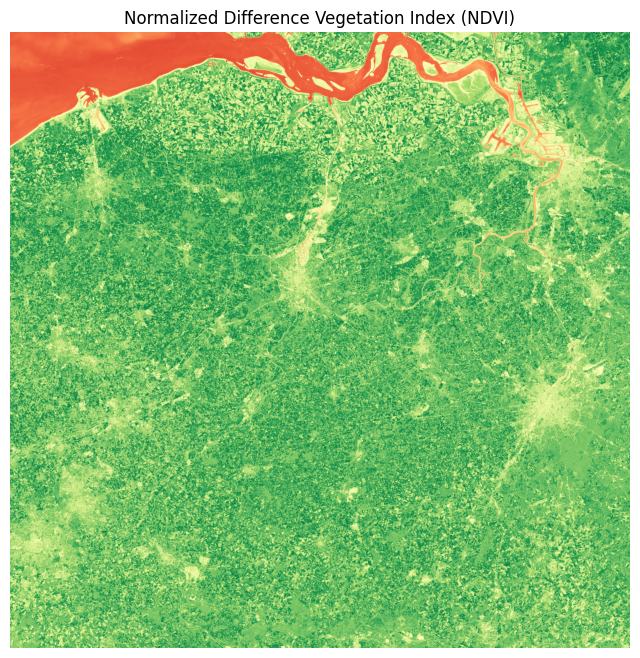

In [41]:
plt.figure(figsize=(8, 8))
## Note: ndvi.imshow did not work here!
plt.imshow(ndvi,cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Normalized Difference Vegetation Index (NDVI)')
## plt.xlabel('X-coordinate')
## plt.ylabel('Y-coordinate')
## plt.grid(False) 
plt.axis('tight') 
plt.axis("off")
plt.show()

### Visualisation: Clipping the true color and NDVI image

In order to clip the NDVI to the ROI of Brussels, we first need to ensure that Coordinate Systems are the same between the ROI and the Sentinel-2 images.

In [42]:
print(f'The CRS for the Brussels area is {gdf.crs}')

The CRS for the Brussels area is EPSG:4326


To retrieve the CRS from the Sentinel 2, we can use the the filtered items we got from pystac itself. At the time of writing, we could not discover the projection in the zarr data itself:

In [43]:
s2_epsg = items_s2_filtered[1].properties['proj:code']
print(f'The Sentinel data is in the {s2_epsg} projection')

## This did not give the epsg projection and threw an error:
## ds.attrs["stac_discovery"]["properties"]["proj:epsg"]

The Sentinel data is in the EPSG:32631 projection


In [44]:
# Code adapted from:
# https://www.geopythontutorials.com/notebooks/xarray_processing_satellite_images.html
geometry = gdf.to_crs(s2_epsg).geometry
geometry.crs

<Projected CRS: EPSG:32631>
Name: WGS 84 / UTM zone 31N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 0°E and 6°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Andorra. Belgium. Benin. Burkina Faso. Denmark - North Sea. France. Germany - North Sea. Ghana. Luxembourg. Mali. Netherlands. Niger. Nigeria. Norway. Spain. Togo. United Kingdom (UK) - North Sea.
- bounds: (0.0, 0.0, 6.0, 84.0)
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

If we do not set the CRS of the data array, this will throw an error:

In [45]:
# Also convert to UTM now:
ndvi = ndvi.rio.write_crs(s2_epsg, inplace=True)
ndvi.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]')

In [46]:
ndvi_clipped = ndvi.rio.clip(geometry)
print(type(ndvi_clipped))

<class 'xarray.core.dataarray.DataArray'>


/opt/conda/lib/python3.12/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 28.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


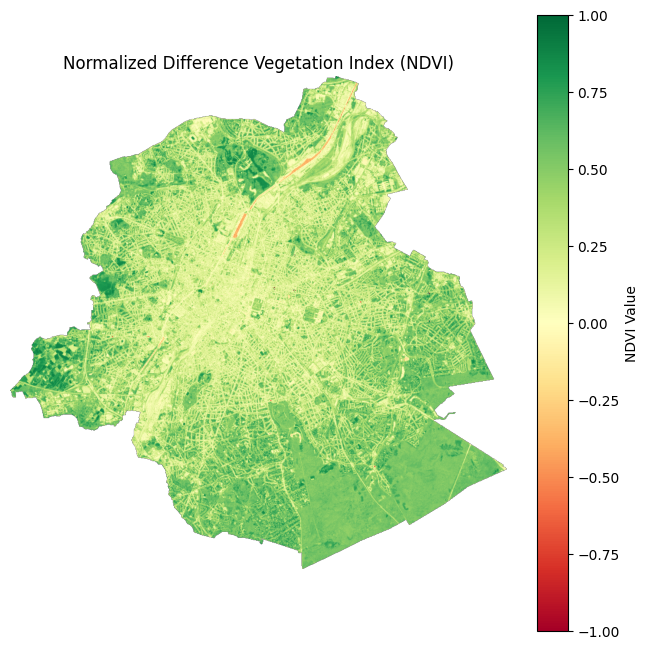

In [47]:
## Need to fix the plotting with Dask still
plt.figure(figsize=(8, 8))
img = plt.imshow(ndvi_clipped, cmap='RdYlGn', vmin=-1, vmax=1)

plt.title('Normalized Difference Vegetation Index (NDVI)')
plt.grid(False)
plt.axis("off")

# Add color legend
cbar = plt.colorbar(img)
cbar.set_label("NDVI Value")

plt.show()

In [48]:
rgb = rgb.rio.write_crs(s2_epsg, inplace=True)
rgb.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]')

In [49]:
rgb_clipped = rgb.rio.clip(geometry) 

/opt/conda/lib/python3.12/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 28.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


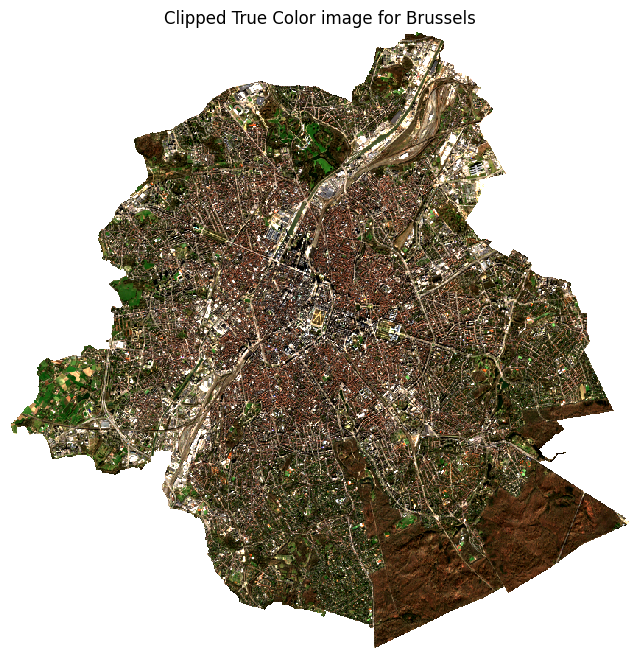

In [50]:
## Need to get rid of warning and send data to Dask
rgb_clipped.plot.imshow(robust=True, figsize=(8,8))

plt.title('Clipped True Color image for Brussels')
plt.grid(False)
plt.axis("off")

plt.show()

The brown colour at the bottom in the South-East of the image is actually a forest. 

In [51]:
print(type(ndvi_clipped))
print(type(rgb_clipped))

<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>


## Sentinel 3: Land surface temperature

Above, our Sentinel-2 image was selected for March 5th 2026. In order to narrow down our search, we only look at that date in March:

In [52]:
## We only select the date that matches the Sentinel-2 data
period_lst = "2026-03-05/2026-03-05"

In [53]:
items_s3 = eopf_catalog.search(
    collections= 'sentinel-3-slstr-l2-lst',
    intersects=aoi,
    datetime=period_lst
   ).item_collection()

In [54]:
print(f'There are {len(items_s3)} items in the collection.')

There are 8 items in the collection.


Again, to get a rough understanding of the data we print out the first images in the collection:

In [55]:
for item in items_s3:
    print(item)

<Item id=S3B_SL_2_LST____20260305T213111_20260305T213411_20260306T005022_0179_117_243_0720_ESA_O_NR_004>
<Item id=S3B_SL_2_LST____20260305T213111_20260305T213411_20260307T051530_0179_117_243_0720_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260305T202854_20260305T203154_20260307T075347_0179_136_385_0720_PS1_O_NT_004>
<Item id=S3A_SL_2_LST____20260305T202854_20260305T203154_20260305T230310_0179_136_385_0720_PS1_O_NR_004>
<Item id=S3A_SL_2_LST____20260305T104359_20260305T104659_20260305T130659_0179_136_379_1980_PS1_O_NR_004>
<Item id=S3A_SL_2_LST____20260305T104359_20260305T104659_20260306T220413_0179_136_379_1980_PS1_O_NT_004>
<Item id=S3B_SL_2_LST____20260305T100817_20260305T101117_20260305T123343_0179_117_236_2160_ESA_O_NR_004>
<Item id=S3B_SL_2_LST____20260305T100817_20260305T101117_20260306T180331_0180_117_236_2160_ESA_O_NT_004>


We also see several things (sentiwiki, page 27):

- **NR versus NT**: NR stands for Near Real Time processing and NT stands for Non-Time critical. We can also see this at the dates of processing. If we take the first and the second items from the list above, where the second file (having NT) is processed at a later data of aquisition.
- **S3A versus S3B**: The S3A and S3B satellites capture LST during different times of the day.
In order to understand the data better, let us take one item:

In [56]:
item = items_s3[0]
## item ## Please uncomment if you want to see more details

Similar to the case of the Sentinel-2 data, we can narrow down the search. If we further want to narrow the search, we can apply two filters:

In [57]:
## Part of script obtained from:
## https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/62_sardinia_s3_lst.html
## and: 
## 
filters = {
    "deprecated":{'eq': False},
    "product:timeliness_category": {'eq':'NT'} 
}

Rerun the query:

In [58]:
items_s3 = eopf_catalog.search(
    collections= 'sentinel-3-slstr-l2-lst',
    intersects=aoi,
    query = filters,
    datetime=period_lst
   ).item_collection()

In [59]:
print(f'There are {len(items_s3)} items in the collection.')

There are 4 items in the collection.


In [60]:
for item in items_s3:
    print(item)

<Item id=S3B_SL_2_LST____20260305T213111_20260305T213411_20260307T051530_0179_117_243_0720_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260305T202854_20260305T203154_20260307T075347_0179_136_385_0720_PS1_O_NT_004>
<Item id=S3A_SL_2_LST____20260305T104359_20260305T104659_20260306T220413_0179_136_379_1980_PS1_O_NT_004>
<Item id=S3B_SL_2_LST____20260305T100817_20260305T101117_20260306T180331_0180_117_236_2160_ESA_O_NT_004>


In [61]:
list_urls_lst = []

for item in items_s3:
    ## print(f'processing item:\n {item}')
    item_asset = item.get_assets(media_type=MediaType.ZARR)
    item_url = item_asset['product'].href
    list_urls_lst.append(item_url)
    ## print(item_url)
    # url = item['product'].href
    # print(url)

list_urls_lst

['https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s03slslst-eu/05/products/cpm_v262/S3B_SL_2_LST____20260305T213111_20260305T213411_20260307T051530_0179_117_243_0720_ESA_O_NT_004.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s03slslst-eu/05/products/cpm_v262/S3A_SL_2_LST____20260305T202854_20260305T203154_20260307T075347_0179_136_385_0720_PS1_O_NT_004.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s03slslst-eu/05/products/cpm_v262/S3A_SL_2_LST____20260305T104359_20260305T104659_20260306T220413_0179_136_379_1980_PS1_O_NT_004.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s03slslst-eu/05/products/cpm_v262/S3B_SL_2_LST____20260305T100817_20260305T101117_20260306T180331_0180_117_236_2160_ESA_O_NT_004.zarr']

In what follows, we select one url from this list and experiment in order to see what url we will finally select. The code below is based on [this EOPF tutorial](https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/).

Unlike the Sentinel-2, the Sentinel-3 are latitude and longitude (EPSG 4326). Unlike the Sentinel-2, we work with a slightly smaller area. NOTE: In an updated version of this script we may change that and work on a bigger area. 

In [62]:
lst_dt = xr.open_datatree(
    list_urls_lst[3], 
    engine="zarr",
    chunks = "auto"
    )

Following the code in the [EOPF tutorial](https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/), we will mask the data for cloud. 

In [63]:
file_path = lst_dt.encoding['source']
print(file_path)

https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s03slslst-eu/05/products/cpm_v262/S3B_SL_2_LST____20260305T100817_20260305T101117_20260306T180331_0180_117_236_2160_ESA_O_NT_004.zarr


In [64]:
## Code obtained:
## https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/
filename = file_path.split("/")[-1]
print(filename)

time_str = filename.split("____")[1].split("_")[0]
dt = datetime.strptime(time_str, "%Y%m%dT%H%M%S")
time_ns = np.datetime64(dt, "ns")

S3B_SL_2_LST____20260305T100817_20260305T101117_20260306T180331_0180_117_236_2160_ESA_O_NT_004.zarr


In [65]:
ds_qual = xr.open_dataset(file_path, engine="zarr", group="quality")

In [66]:
## Apply cloud masking
## Code obtained from:
## https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/
confidence_in = ds_qual["confidence_in"]
cloud_mask = confidence_in < 16384  # Threshold 
masked_lst = lst_dt.measurements["lst"].where(cloud_mask)

In [67]:
## TO DO: Write this in a function
extent = gdf.total_bounds
print(f'The extent is {extent}')

lon_min, lat_min, lon_max, lat_max = extent
print(lon_min, lat_min, lon_max, lat_max)

## We buffer the area a bit:
lon_min_extended = lon_min - 0.02
lon_max_extended = lon_max + 0.02
lat_min_extended = lat_min - 0.02
lat_max_extended = lat_max + 0.02

print(f'The extended extent is {lon_min_extended}, {lon_max_extended}, {lat_min_extended}, {lat_max_extended}')

The extent is [ 4.24376514 50.76368008  4.48227115 50.91390132]
4.243765141705198 50.76368007545227 4.482271147586886 50.913901323433834
The extended extent is 4.223765141705198, 4.502271147586885, 50.74368007545227, 50.93390132343384


Next, we work on a smaller area surrounding the Brussels area. More specifically, we extract the corner longitudes and latitudes from the Geopandas file above:

In [68]:
mask = (
        (lst_dt.measurements["longitude"] >= lon_min)
        & (lst_dt.measurements["longitude"] <= lon_max)
        & (lst_dt.measurements["latitude"] >= lat_min)
        & (lst_dt.measurements["latitude"] <= lat_max)
    )

In [69]:
rows, cols = np.where(mask)

In [70]:
row_min, row_max = rows.min(), rows.max()
col_min, col_max = cols.min(), cols.max()

print(row_min, row_max, col_min, col_max)

67 86 682 701


In [71]:
# Subsetting the masked LST
masked_lst_subset = masked_lst.isel(
        rows=slice(row_min, row_max + 1), columns=slice(col_min, col_max + 1)
)

Changing the latitude and longitude values too:

In [72]:
lat2d = lst_dt.measurements["latitude"].isel(
        rows=slice(row_min, row_max + 1), columns=slice(col_min, col_max + 1)
    )
lon2d = lst_dt.measurements["longitude"].isel(
        rows=slice(row_min, row_max + 1), columns=slice(col_min, col_max + 1)
    )

As pointed out in this [EOPF tutorial](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/610_s2_s3_fusion.html), the Sentinel 3 data have a swath geometry and are not on a regular grid. Hence, we need to do some re-gridding:

In [73]:
# Regrid
## Code obtained from:
## https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/
target_resolution = 0.01
n_points_lat = int(np.ceil((lat_max - lat_min) / target_resolution)) + 1
n_points_lon = int(np.ceil((lon_max - lon_min) / target_resolution)) + 1
lon_grid, lat_grid = np.meshgrid(
np.linspace(lon_min, lon_max, n_points_lon),
np.linspace(lat_min, lat_max, n_points_lat),
)

In [74]:
regridded_lst = griddata(
        (lon2d.values.ravel(), lat2d.values.ravel()),
        masked_lst_subset.values.ravel(),
        (lon_grid, lat_grid),
        method="linear",
    )

In [75]:
# Create a new dataset with regridded data
## We have to put the coordinates into x and y 
## as otherwise rio.xarray will protest with clipping
## This is a change from this code:
## as otherwise we will have error
## https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/
regridded_ds_lst = xr.Dataset(
        data_vars={"lst": (["y", "x"], regridded_lst)},
        coords={"y": lat_grid[:, 0], "x": lon_grid[0, :], "time": time_ns},
    )
regridded_ds_lst

<xarray.Dataset> Size: 4kB
Dimensions:  (y: 17, x: 25)
Coordinates:
  * y        (y) float64 136B 50.76 50.77 50.78 50.79 ... 50.89 50.9 50.9 50.91
  * x        (x) float64 200B 4.244 4.254 4.264 4.274 ... 4.462 4.472 4.482
    time     datetime64[ns] 8B 2026-03-05T10:08:17
Data variables:
    lst      (y, x) float64 3kB nan nan nan 288.6 ... 290.0 288.7 288.3 nan

Put all the data back into a new xarray dataset:

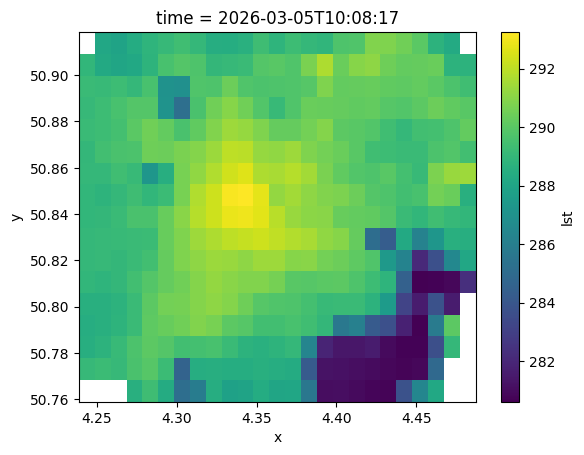

In [76]:
regridded_ds_lst.lst.plot()

In order to clip this to the ROI, we need to assign a CRS to the data as currently, the data has none. Again, we use the rioxarray Python package:

In [77]:
regridded_ds_lst.rio.write_crs("EPSG:4326", inplace=True)
regridded_ds_lst

<xarray.Dataset> Size: 4kB
Dimensions:      (y: 17, x: 25)
Coordinates:
  * y            (y) float64 136B 50.76 50.77 50.78 50.79 ... 50.9 50.9 50.91
  * x            (x) float64 200B 4.244 4.254 4.264 4.274 ... 4.462 4.472 4.482
    time         datetime64[ns] 8B 2026-03-05T10:08:17
    spatial_ref  int64 8B 0
Data variables:
    lst          (y, x) float64 3kB nan nan nan 288.6 ... 290.0 288.7 288.3 nan

We can use the AOI in the EPSG 4326 to clip:

In [78]:
geometry_4326 = gdf.geometry
geometry_4326.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In our understanding, the latitude and longitude coordinates need to be in "x" and "y" for clipping to work. 

In [79]:
regridded_ds_lst

<xarray.Dataset> Size: 4kB
Dimensions:      (y: 17, x: 25)
Coordinates:
  * y            (y) float64 136B 50.76 50.77 50.78 50.79 ... 50.9 50.9 50.91
  * x            (x) float64 200B 4.244 4.254 4.264 4.274 ... 4.462 4.472 4.482
    time         datetime64[ns] 8B 2026-03-05T10:08:17
    spatial_ref  int64 8B 0
Data variables:
    lst          (y, x) float64 3kB nan nan nan 288.6 ... 290.0 288.7 288.3 nan

In [80]:
regridded_ds_lst = regridded_ds_lst.rio.write_crs("EPSG:4326")
regridded_ds_lst_clipped = regridded_ds_lst.rio.clip(geometry_4326)


In [81]:
regridded_ds_lst_clipped

<xarray.Dataset> Size: 3kB
Dimensions:      (y: 15, x: 23)
Coordinates:
  * y            (y) float64 120B 50.77 50.78 50.79 50.8 ... 50.89 50.9 50.9
  * x            (x) float64 184B 4.254 4.264 4.274 4.284 ... 4.452 4.462 4.472
    time         datetime64[ns] 8B 2026-03-05T10:08:17
    spatial_ref  int64 8B 0
Data variables:
    lst          (y, x) float64 3kB nan nan nan nan nan ... nan nan nan nan nan

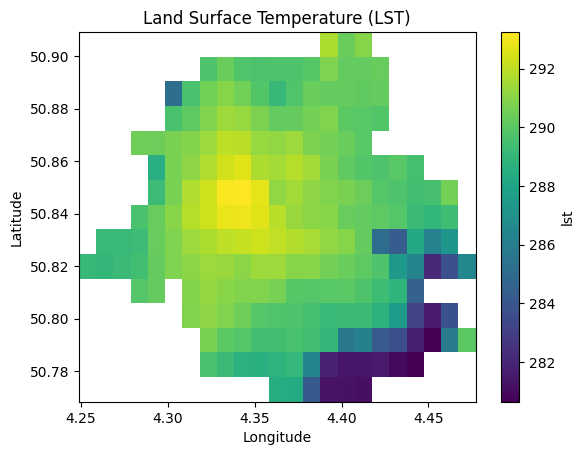

In [82]:
regridded_ds_lst_clipped["lst"].plot()
plt.title("Land Surface Temperature (LST)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()
plt.show()

We can clearly notice that in the South-East we have cooler temperatures. As mentioned above, this area is a forest area. Also, in the North-West (where we have some greenery) area we can see cooler temperatures while in the centre of the city of Brussels we see higher temperatures.

<hr>

## 💪 Now it is your turn

### Task 1: Change your study area
* Go to https://geojson.io/ and draw an Area Of Interest (AOI) and save it as a GeoJSON.
* Move the GeoJSON file to a directory and read it into the script.
* Find out which Sentinel-2 tiles are relevant for your AOI using the visualisation script above. In this tutorial, we do not work with multiple Sentinel-2 tiles yet.
* Alternatively, you can also work with bounding box coordinates and use http://bboxfinder.com/. Rather than using "intersects", you can use "bbox" option instead when you extract the images using the eopf catalog search in pystac. There are multiple examples in the EOPF tutorials that use this approach.

### Task 2: Experiment with the parameters and filters
* Compare data availability across different months for the Sentinel-2 and Sentinel-3 data and change the parameters for the dates.
* Try to find matching dates between the two Sentinel datasets.
* Try to experiment with different seasons (winter, summer). At the time of writing this tutorial, this is currently very much subject to the current data availability.
### Task 3: Try different indices
* You can experiment with different indices such as Modified Normalised Difference Water Index (MNDWI), Normalised Different Building Index (NDBI), etc.
* Compare the maps of these indices with the maps of the LST. What can you observe?

### Task 4: Create a map for the diurnal differences in Land Surface Temperature
* Look at the differences between the Land Surface Temperature (LST) for the ROI between daytime and nighttime LST. As an example, you can follow this [EOPF tutorial of the Normalised Burn ratio](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/63_sardinia_dNBR.html) to create a map with differences.

## Conclusion

In this notebook, we did an exploratory analysis and studied whether visually there is a relation between Land Surface Temperature (LST) and the Normalised Difference Vegetation Index (NDVI) for Brussels, Belgium. At first sight, we can see that areas with more greenery have a higher NDVI and a lower LST and we suspect that both variables will have a negative correlation when we do a more systematic statistical analysis (e.g. regression and correlation).

In this tutorial, we learnt to use the Python pystac library and how to query Sentinel-2 and Sentinel-3 and find matching time periods for our analysis. Furthermore, instead of using latitude and longitude coordinates, we learnt to clip NDVI and LST to the Brussels area itself.

## What's next?

* **Mosaicing:** In the current code, we only used one tile of Sentinel-2. In a follow-up code, we would like to repeat the workflow if the ROI spans two or more Sentinel-2 tiles.
* Create a **median composite** both for the NDVI and LST and clip this to the AOI. This code allows one to work with different files simultaneously across time.
* **Overlay the Sentinel-2 NDVI data with the Sentinel-3 LST** and do some analytics based on the pixel values of both datasets (e.g. correlation, regression). Doing this, one has to (perfectly) align the pixels of both Sentinel datasets.
* We did not **incorporate the use of cloud masks** in this tutorial. We carefully selected an image with very low cloud cover here. However, it possible that the image has more cloud cloud cover. In the next tutorial(s), we hope to incorporate this and mask the cloudy pixels. 

## References

Roy, B., & Bari, E. (2022). Examining the relationship between land surface temperature and landscape features using spectral indices with Google Earth Engine. Heliyon, 8(9).

https://eopf-toolkit.github.io/eopf-101/

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html#prerequisites

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html

https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/62_sardinia_s3_lst.html

https://sentiwiki.copernicus.eu/__attachments/1672112/OMPC.ACR.HBK.002%20-%20Sentinel%203%20SLSTR%20Land%20Handbook%202024%20-%201.4.pdf?inst-v=96021aea-734a-44d2-9ca8-2228c7de7290#:~:text=Land%20surface%20temperature%20products,ice%20and%20inland%20water%20pixels.

https://www.geopythontutorials.com/notebooks/dask_median_composite.html from Ujaval Gandhi

https://stacspec.org/en/tutorials/reading-stac-planetary-computer/

https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/

https://www.geopythontutorials.com/notebooks/xarray_processing_satellite_images.html

[Mapping and Data Visualization with Python Course](https://spatialthoughts.com/courses/python-dataviz/) by Ujaval Gandhi www.spatialthoughts.com

https://pystac-client.readthedocs.io/en/latest/api.html

https://eopf-sample-service.github.io/eopf-sample-notebooks/

https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/

https://stackoverflow.com/questions/72215741/add-projection-to-rioxarray-dataset-in-python

https://corteva.github.io/rioxarray/stable/

https://docs.xarray.dev/en/stable/